# Week 10 - ARIA v70

## Analysis and application of Remote sensing & geospatial information

In [2]:
import os
from dotenv import load_dotenv
import pystac_client
import planetary_computer as pc
import stackstac
import numpy as np
import matplotlib.pyplot as plt

# 載入 .env 檔案
load_dotenv()

# 從環境變數讀取 BBOX 並轉換為浮點數列表
BBOX_WEST = float(os.getenv('BBOX_WEST'))
BBOX_SOUTH = float(os.getenv('BBOX_SOUTH'))
BBOX_EAST = float(os.getenv('BBOX_EAST'))
BBOX_NORTH = float(os.getenv('BBOX_NORTH'))
HUALIEN_BBOX = [BBOX_WEST, BBOX_SOUTH, BBOX_EAST, BBOX_NORTH]

# 讀取時間範圍
PRE_DATE_RANGE = os.getenv('PRE_DATE_RANGE')
POST_DATE_RANGE = os.getenv('POST_DATE_RANGE')

print("BBOX:", HUALIEN_BBOX)
print("災前觀測期:", PRE_DATE_RANGE)
print("災後觀測期:", POST_DATE_RANGE)

BBOX: [121.2574, 23.6546, 121.4984, 23.7447]
災前觀測期: 2025-10-01/2025-11-05
災後觀測期: 2025-11-12/2025-11-30


### Captain's Log 1: 初始化與資料搜尋

透過 Planetary Computer STAC API 搜尋災後 (2025-11-12 至 2025-11-30) 覆蓋花蓮馬太鞍溪區域的 Sentinel-1 RTC 雷達影像。列出符合條件的場景清單，並確認其軌道方向 (Orbit Direction)，以便後續挑選災前/災後一致的影像。

In [3]:
# 建立與 Planetary Computer 的連線
catalog = pystac_client.Client.open(
    'https://planetarycomputer.microsoft.com/api/stac/v1',
    modifier=pc.sign_inplace,
)

# 1. 搜尋災後影像 (Post-disaster)
search_post = catalog.search(
    collections=['sentinel-1-rtc'],
    bbox=HUALIEN_BBOX,
    datetime=POST_DATE_RANGE,
)
items_post = list(search_post.items())

# 2. 搜尋災前影像 (Pre-disaster)
search_pre = catalog.search(
    collections=['sentinel-1-rtc'],
    bbox=HUALIEN_BBOX,
    datetime=PRE_DATE_RANGE,
)
items_pre = list(search_pre.items())

print(f"總共找到 {len(items_pre)} 筆災前影像，{len(items_post)} 筆災後影像。\n")

# 3. 列出影像資訊，方便我們挑選
print("=== 災後影像清單 (Post) ===")
for item in items_post:
    date = item.datetime.strftime('%Y-%m-%d')
    orbit = item.properties.get('sat:orbit_state')
    print(f"日期: {date} | 軌道: {orbit} | ID: {item.id}")

print("\n=== 災前影像清單 (Pre) ===")
for item in items_pre:
    date = item.datetime.strftime('%Y-%m-%d')
    orbit = item.properties.get('sat:orbit_state')
    print(f"日期: {date} | 軌道: {orbit} | ID: {item.id}")

總共找到 11 筆災前影像，5 筆災後影像。

=== 災後影像清單 (Post) ===
日期: 2025-11-29 | 軌道: ascending | ID: S1A_IW_GRDH_1SDV_20251129T100121_20251129T100146_062091_07C4FB_rtc
日期: 2025-11-25 | 軌道: descending | ID: S1C_IW_GRDH_1SDV_20251125T215150_20251125T215215_005176_00A44D_rtc
日期: 2025-11-23 | 軌道: ascending | ID: S1C_IW_GRDH_1SDV_20251123T100017_20251123T100042_005140_00A313_rtc
日期: 2025-11-19 | 軌道: descending | ID: S1A_IW_GRDH_1SDV_20251119T215250_20251119T215315_061952_07BF82_rtc
日期: 2025-11-13 | 軌道: descending | ID: S1C_IW_GRDH_1SDV_20251113T215150_20251113T215215_005001_009E5E_rtc

=== 災前影像清單 (Pre) ===
日期: 2025-11-05 | 軌道: ascending | ID: S1A_IW_GRDH_1SDV_20251105T100123_20251105T100148_061741_07B75F_rtc
日期: 2025-11-01 | 軌道: descending | ID: S1C_IW_GRDH_1SDV_20251101T215151_20251101T215216_004826_009893_rtc
日期: 2025-10-30 | 軌道: ascending | ID: S1C_IW_GRDH_1SDV_20251030T100018_20251030T100043_004790_00975D_rtc
日期: 2025-10-26 | 軌道: descending | ID: S1A_IW_GRDH_1SDV_20251026T215251_20251026T215316_061602_07

### Captain's Log 2: 影像篩選與預處理

根據 STAC 搜尋結果，選定 11-13 (災後) 與 11-01 (災前) 這兩組相同為 descending 軌道的影像進行分析。將 VV 頻段轉換為 dB 值，並套用 Median Filter 以消除 SAR 特有的斑點雜訊 (Speckle noise)。

In [4]:
import scipy.ndimage

# 1. 精準挑選我們決定的那兩張影像
post_item = next(item for item in items_post if item.datetime.strftime('%Y-%m-%d') == '2025-11-13')
pre_item = next(item for item in items_pre if item.datetime.strftime('%Y-%m-%d') == '2025-11-01')

print(f"選定的災前影像: {pre_item.id}")
print(f"選定的災後影像: {post_item.id}")

# 2. 透過 stackstac 將 STAC Item 轉為 xarray DataArray (只取 VV 頻段)
# 注意：這裡的解析度設為 10m，並鎖定在我們的 HUALIEN_BBOX
cube = stackstac.stack(
    [pc.sign(pre_item), pc.sign(post_item)],
    assets=['vv'], 
    epsg=32651, # 台灣所在的 UTM 投影區帶 (WGS84 UTM Zone 51N)
    resolution=10, 
    bounds_latlon=HUALIEN_BBOX
)

# 觸發計算，將資料拉到記憶體中 (因為範圍不大，這步應該滿快的)
vv_linear = cube.compute()

# 將災前(0)與災後(1)的資料分開，並去除多餘的維度
vv_pre_linear = vv_linear[0].squeeze().astype(np.float32)
vv_post_linear = vv_linear[1].squeeze().astype(np.float32)

# 3. 將 Linear scale 轉換為 dB (分貝) scale
vv_pre_db = 10 * np.log10(vv_pre_linear.values)
vv_post_db = 10 * np.log10(vv_post_linear.values)

# 4. 斑點雜訊濾波 (Speckle Filtering) - 使用 5x5 的中值濾波器
vv_post_filtered = scipy.ndimage.median_filter(vv_post_db, size=5)
vv_pre_filtered = scipy.ndimage.median_filter(vv_pre_db, size=5)

print("資料讀取與濾波完成！矩陣大小:", vv_post_filtered.shape)

選定的災前影像: S1C_IW_GRDH_1SDV_20251101T215151_20251101T215216_004826_009893_rtc
選定的災後影像: S1C_IW_GRDH_1SDV_20251113T215150_20251113T215215_005001_009E5E_rtc
資料讀取與濾波完成！矩陣大小: (1026, 2470)


### Captain's Log 3: 直方圖分析與初步閾值測試

繪製災後雷達影像的後向散射值 (dB) 直方圖，觀察數值分布。並套用 .env 中設定的 SAR_THRESHOLD (-18 dB) 來生成初步的二元水體遮罩 (Binary Water Mask)，檢視該閾值是否能有效區分水體與陸地。

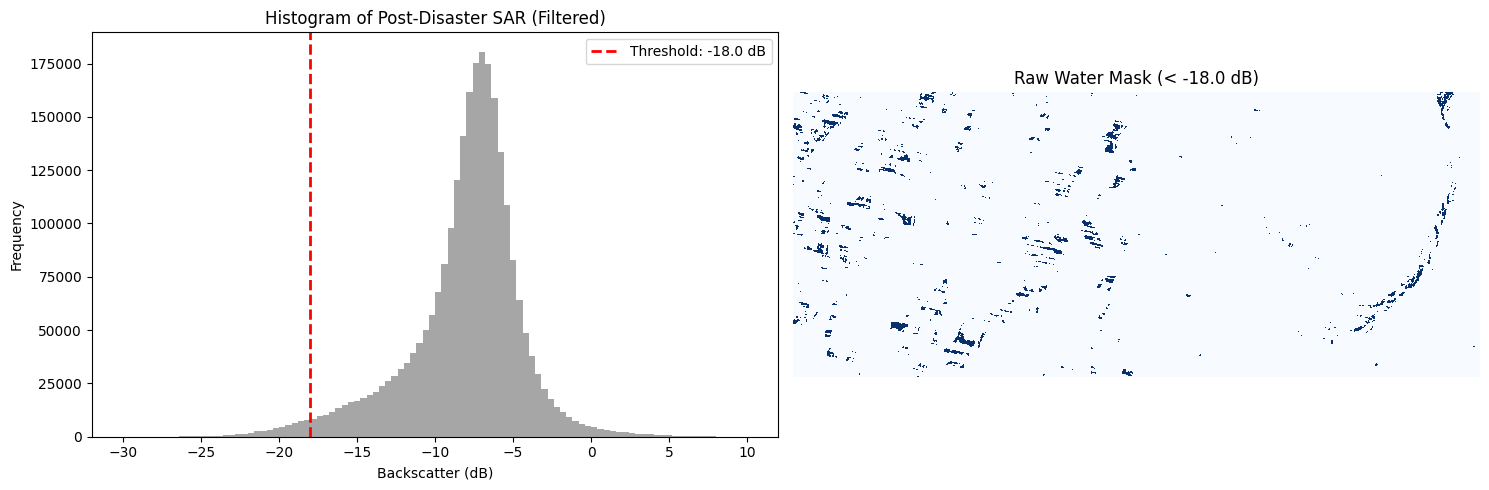

初步偵測到的水體像素數量: 52398


In [5]:
# 從環境變數讀取你設定的閾值，並自動過濾掉 .env 裡的註解
raw_threshold = os.getenv('SAR_THRESHOLD', '-18.0')
# 把字串用 '#' 切開，只取第一部分(數字)，清掉多餘空白後再轉成小數
sar_threshold = float(str(raw_threshold).split('#')[0].strip())

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# 1. 繪製直方圖 (Histogram)
# 排除掉可能存在的 NaN (空值) 像素再畫圖
valid_pixels = vv_post_filtered[~np.isnan(vv_post_filtered)]
ax[0].hist(valid_pixels, bins=100, range=(-30, 10), color='gray', alpha=0.7)
ax[0].axvline(sar_threshold, color='red', linestyle='dashed', linewidth=2, 
              label=f'Threshold: {sar_threshold} dB')
ax[0].set_title('Histogram of Post-Disaster SAR (Filtered)')
ax[0].set_xlabel('Backscatter (dB)')
ax[0].set_ylabel('Frequency')
ax[0].legend()

# 2. 預覽閾值效果 (初步的水體遮罩)
raw_water_mask = (vv_post_filtered < sar_threshold) & (~np.isnan(vv_post_filtered))
ax[1].imshow(raw_water_mask, cmap='Blues', interpolation='none')
ax[1].set_title(f'Raw Water Mask (< {sar_threshold} dB)')
ax[1].axis('off')

plt.tight_layout()
plt.show()

print(f"初步偵測到的水體像素數量: {np.sum(raw_water_mask)}")

### Captain's Log 4: 清理與連通元件過濾

針對初步的 SAR 水體遮罩進行清理，首先移除細小雜點，接著計算連通元件 (Connected Components) 的大小，過濾掉面積小於 MIN_WATER_PIXELS (預設 50 px) 的零星水窪，萃取出真實且連續的淹水範圍。

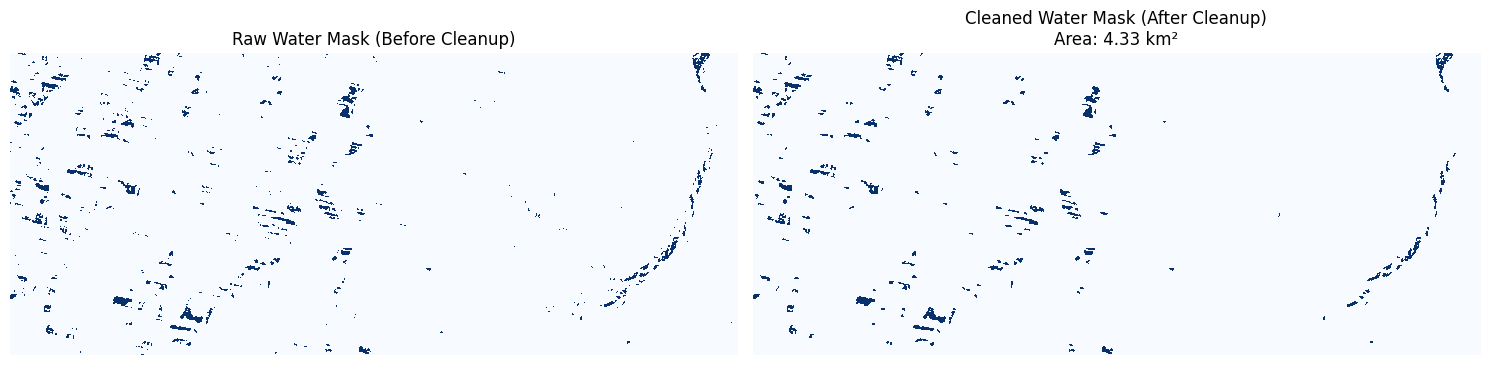

----------------------------------------
Task 1 統計數據:
淹水面積: 4.33 km²
水體像素數量: 43322 pixels
淹水區平均後向散射: -20.21 dB
----------------------------------------


In [7]:
from scipy.ndimage import binary_opening, label
import matplotlib.patches as mpatches

# 1. 形態學開運算 (去除孤立小雜點)
# 使用 3x3 的結構元素
structure = np.ones((3, 3), dtype=bool)
opened_mask = binary_opening(raw_water_mask, structure=structure)

# 2. 連通元件過濾 (去除面積太小的假水體)
# [修正這裡] 自動過濾掉 .env 裡的註解
raw_min_pixels = os.getenv('MIN_WATER_PIXELS', '50')
min_pixels = int(str(raw_min_pixels).split('#')[0].strip())

labeled_mask, num_features = label(opened_mask)
component_sizes = np.bincount(labeled_mask.ravel())

# 找出大小 >= min_pixels 的元件 ID (跳過背景 ID 0)
valid_components = np.where(component_sizes >= min_pixels)[0]
valid_components = valid_components[valid_components > 0]

# 建立最終的乾淨遮罩
cleaned_water_mask = np.isin(labeled_mask, valid_components)

# 3. 計算統計數據 (1 像素 = 10m x 10m = 100 m² = 0.0001 km²)
water_pixel_count = np.sum(cleaned_water_mask)
flooded_area_km2 = water_pixel_count * 0.0001

# 計算淹水區的平均後向散射值 (Mean Backscatter)
mean_backscatter = np.nanmean(vv_post_filtered[cleaned_water_mask])

# 4. 繪圖比對：清理前 vs 清理後
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

ax[0].imshow(raw_water_mask, cmap='Blues', interpolation='none')
ax[0].set_title('Raw Water Mask (Before Cleanup)')
ax[0].axis('off')

ax[1].imshow(cleaned_water_mask, cmap='Blues', interpolation='none')
ax[1].set_title(f'Cleaned Water Mask (After Cleanup)\nArea: {flooded_area_km2:.2f} km²')
ax[1].axis('off')

plt.tight_layout()
plt.show()

# 輸出作業要求的數據表資訊
print("-" * 40)
print(f"Task 1 統計數據:")
print(f"淹水面積: {flooded_area_km2:.2f} km²")
print(f"水體像素數量: {water_pixel_count} pixels")
print(f"淹水區平均後向散射: {mean_backscatter:.2f} dB")
print("-" * 40)

### Captain's Log 5: 尋找 Sentinel-2 光學影像

透過 STAC 搜尋與 SAR 災後影像 (2025-11-12 至 2025-11-30) 同時期的 Sentinel-2 (L2A) 光學影像。並檢視其雲量 (Cloud Cover) 百分比，以挑選雲遮蔽最少的一張來計算 NDWI。

In [8]:
# 搜尋災後的 Sentinel-2 光學影像
search_s2 = catalog.search(
    collections=['sentinel-2-l2a'],
    bbox=HUALIEN_BBOX,
    datetime=POST_DATE_RANGE,
)

items_s2 = list(search_s2.items())
print(f"總共找到 {len(items_s2)} 筆災後 Sentinel-2 光學影像。\n")

# 列出影像資訊，觀察雲量
print("=== 災後光學影像清單 (Sentinel-2) ===")
# 為了方便挑選，我們依照雲量由低到高排序
items_s2_sorted = sorted(items_s2, key=lambda x: x.properties.get('eo:cloud_cover', 100))

for item in items_s2_sorted:
    date = item.datetime.strftime('%Y-%m-%d')
    cloud_cover = item.properties.get('eo:cloud_cover', 100)
    print(f"日期: {date} | 雲量: {cloud_cover:5.2f}% | ID: {item.id}")

總共找到 5 筆災後 Sentinel-2 光學影像。

=== 災後光學影像清單 (Sentinel-2) ===
日期: 2025-11-30 | 雲量: 44.91% | ID: S2C_MSIL2A_20251130T023051_R046_T51QUG_20251130T052811
日期: 2025-11-22 | 雲量: 46.22% | ID: S2A_MSIL2A_20251122T023141_R046_T51QUG_20251122T073215
日期: 2025-11-15 | 雲量: 46.25% | ID: S2B_MSIL2A_20251115T022849_R046_T51QUG_20251115T041115
日期: 2025-11-20 | 雲量: 75.38% | ID: S2C_MSIL2A_20251120T024011_R046_T51QUG_20251120T052912
日期: 2025-11-25 | 雲量: 78.18% | ID: S2B_MSIL2A_20251125T022929_R046_T51QUG_20251125T040807


### Captain's Log 6: 光學影像 NDWI 與雲遮罩萃取

讀取綠光 (B03)、近紅外光 (B08) 以及場景分類圖層 (SCL)。計算 NDWI 以偵測地表水體，並建立雲層與雲影遮罩

In [9]:
# 1. 挑選雲量最低的光學影像 (第一筆)
best_s2_item = items_s2_sorted[0]
print(f"選用的光學影像: {best_s2_item.id}")
print(f"雲量: {best_s2_item.properties.get('eo:cloud_cover'):.2f}%\n")

# 2. 透過 stackstac 讀取 B03(Green), B08(NIR), SCL(場景分類)
# 這裡使用與 SAR 完全相同的 epsg, resolution 和 bounds，盡可能讓網格自然對齊
s2_cube = stackstac.stack(
    [pc.sign(best_s2_item)],
    assets=['B03', 'B08', 'SCL'],
    epsg=32651,
    resolution=10,
    bounds_latlon=HUALIEN_BBOX
).compute()

# 移除時間維度
s2_data = s2_cube[0].squeeze()

# 3. 取出各頻段並轉換型別
green = s2_data.sel(band='B03').values.astype(np.float32)
nir = s2_data.sel(band='B08').values.astype(np.float32)
scl = s2_data.sel(band='SCL').values.astype(np.uint8)

# 4. 計算 NDWI = (Green - NIR) / (Green + NIR)
# 加上 1e-8 避免分母為 0 的錯誤
ndwi = (green - nir) / (green + nir + 1e-8)

# 從 .env 讀取 NDWI 閾值 (並處理註解字串問題)
raw_ndwi_threshold = os.getenv('NDWI_THRESHOLD', '0.0')
ndwi_threshold = float(str(raw_ndwi_threshold).split('#')[0].strip())

# 5. 建立雲層遮罩 (Cloud Mask)
# Sentinel-2 SCL 定義: 3=雲影, 8=中機率雲, 9=高機率雲, 10=卷雲
cloud_mask = np.isin(scl, [3, 8, 9, 10])

# 建立初步的光學水體遮罩 (NDWI大於閾值)
optical_water_mask = (ndwi > ndwi_threshold)

print("-" * 40)
print(f"SAR 遮罩大小: {cleaned_water_mask.shape}")
print(f"光學 遮罩大小: {optical_water_mask.shape}")

# 6. Grid Alignment (網格對齊防呆機制)
# 有時候雖然 BBOX 相同，但因為座標切分的微小差異會導致 1 pixel 的落差
if cleaned_water_mask.shape != optical_water_mask.shape:
    print("\n⚠️ 警告：SAR 與光學網格大小不一致，啟動 scipy.ndimage.zoom 對齊...")
    from scipy.ndimage import zoom
    zoom_factors = (cleaned_water_mask.shape[0] / optical_water_mask.shape[0],
                    cleaned_water_mask.shape[1] / optical_water_mask.shape[1])
    
    # order=0 代表 nearest neighbor (最近鄰點插值)，適合 boolean 遮罩
    optical_water_mask = zoom(optical_water_mask, zoom_factors, order=0).astype(bool)
    cloud_mask = zoom(cloud_mask, zoom_factors, order=0).astype(bool)
    print("✅ 對齊完成！目前的形狀：", optical_water_mask.shape)
else:
    print("\n✅ SAR 與光學網格已完美對齊！")

選用的光學影像: S2C_MSIL2A_20251130T023051_R046_T51QUG_20251130T052811
雲量: 44.91%

----------------------------------------
SAR 遮罩大小: (1026, 2470)
光學 遮罩大小: (1026, 2470)

✅ SAR 與光學網格已完美對齊！


### Captain's Log 7: 執行感測器融合與確信度分級

將 SAR 遮罩、光學 NDWI 遮罩與雲遮罩進行交集。產出包含四個等級（High Confidence, SAR 表Only, Optical Only, No Detection）的確信度地圖，並計算各分類的面積。

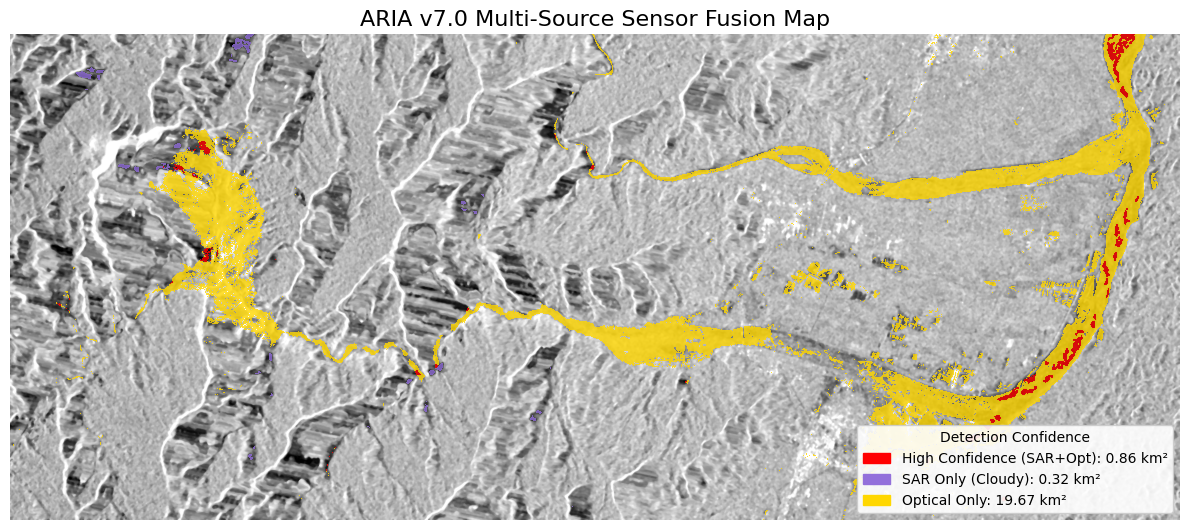

--------------------------------------------------
High confidence zones cover 0.86 km².
SAR-only zones add 0.32 km² of flood detection in cloudy areas.
--------------------------------------------------


In [10]:
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches

# 1. 建立一張全為 0 (No Detection) 的空白畫布，大小跟我們的遮罩一樣
confidence_map = np.zeros_like(cleaned_water_mask, dtype=np.uint8)

# 2. 實作作業的 Fusion Logic (矩陣布林運算)
# ✅ High Confidence (雙證據)：光學有抓到 + SAR有抓到 + 沒被雲遮住
high_conf_cond = (optical_water_mask == True) & (cleaned_water_mask == True) & (cloud_mask == False)
confidence_map[high_conf_cond] = 3

# ✅ SAR Only (Cloudy)：SAR有抓到 + 被雲遮住 (光學無效)
sar_only_cond = (cleaned_water_mask == True) & (cloud_mask == True)
confidence_map[sar_only_cond] = 2

# ✅ Optical Only：光學有抓到 + SAR沒抓到 + 沒被雲遮住
optical_only_cond = (optical_water_mask == True) & (cleaned_water_mask == False) & (cloud_mask == False)
confidence_map[optical_only_cond] = 1

# 3. 計算各分類的面積 (km²)
area_high_conf = np.sum(confidence_map == 3) * 0.0001
area_sar_only = np.sum(confidence_map == 2) * 0.0001
area_optical_only = np.sum(confidence_map == 1) * 0.0001

# 4. 繪圖視覺化
fig, ax = plt.subplots(figsize=(12, 8))

# 定義顏色：0:透明(背景), 1:黃色(光學), 2:紫色(僅SAR/雲區), 3:紅色(高確信度/雙重確認)
cmap_fusion = ListedColormap(['none', '#FFD700', '#9370DB', '#FF0000'])

# 畫底圖 (災後 SAR，幫助對照地形)
ax.imshow(vv_post_filtered, cmap='gray', vmin=-25, vmax=0)

# 疊加確信度地圖
im = ax.imshow(confidence_map, cmap=cmap_fusion, interpolation='none', alpha=0.8)

# 建立圖例 (Legend)
legend_elements = [
    mpatches.Patch(color='#FF0000', label=f'High Confidence (SAR+Opt): {area_high_conf:.2f} km²'),
    mpatches.Patch(color='#9370DB', label=f'SAR Only (Cloudy): {area_sar_only:.2f} km²'),
    mpatches.Patch(color='#FFD700', label=f'Optical Only: {area_optical_only:.2f} km²')
]
ax.legend(handles=legend_elements, loc='lower right', title='Detection Confidence', 
          facecolor='white', framealpha=0.9)

ax.set_title('ARIA v7.0 Multi-Source Sensor Fusion Map', fontsize=16)
ax.axis('off')
plt.tight_layout()
plt.show()

# 輸出作業要求的文字陳述
print("-" * 50)
print(f"High confidence zones cover {area_high_conf:.2f} km².")
print(f"SAR-only zones add {area_sar_only:.2f} km² of flood detection in cloudy areas.")
print("-" * 50)

### Captain's Log 8: DEM 地形過濾 (Topographic Audit)
透過 STAC 載入 Copernicus DEM，計算研究區的坡度 (Slope)。將坡度大於 25 度的區域視為不可能積水的陡坡，並以此過濾確信度地圖，消除因雷達地形效應（如陰影、前縮）造成的誤報。

In [13]:
import xarray as xr

# 1. 透過 STAC 搜尋 Copernicus DEM
search_dem = catalog.search(
    collections=["cop-dem-glo-30"],
    bbox=HUALIEN_BBOX,
)
items_dem = list(search_dem.items())
print(f"找到 {len(items_dem)} 筆 DEM 資料。")

# 2. 讀取 DEM 並對齊網格 (使用與 SAR/光學相同的設定)
# Copernicus DEM 的 asset 名稱是 'data'
dem_cube = stackstac.stack(
    items_dem,
    assets=['data'],
    epsg=32651,
    resolution=10,
    bounds_latlon=HUALIEN_BBOX
).compute()

# 由於 DEM 可能會跨越多個圖幅，我們沿著時間維度取平均/最大值來合併
dem = dem_cube.max(dim='time').squeeze().values.astype(np.float32)

# 3. 計算坡度 (Slope)
# 這裡我們使用 numpy.gradient 計算 X 和 Y 方向的梯度
dy, dx = np.gradient(dem, 10, 10) # 10 是我們的像素解析度 (10m)
slope_rad = np.arctan(np.sqrt(dx**2 + dy**2))
slope_deg = np.degrees(slope_rad)

# 從 .env 讀取坡度閾值 (處理註解)
raw_slope_threshold = os.getenv('SLOPE_THRESHOLD', '25')
slope_threshold = float(str(raw_slope_threshold).split('#')[0].strip())

print(f"使用的坡度過濾閾值: {slope_threshold}°")

找到 1 筆 DEM 資料。
使用的坡度過濾閾值: 25.0°


### Captain's Log 9: 執行地形過濾與誤報分析

將位於坡度 > 25° 且被 SAR 判定為水體的像素標記為地形誤判，計算它們在不同坡度區間（25-35°, 35-45°, >45°）的面積，並將這些誤判從確信度地圖中剔除。產出過濾前後的並排比較圖，以及各坡度區間的誤報移除統計表。

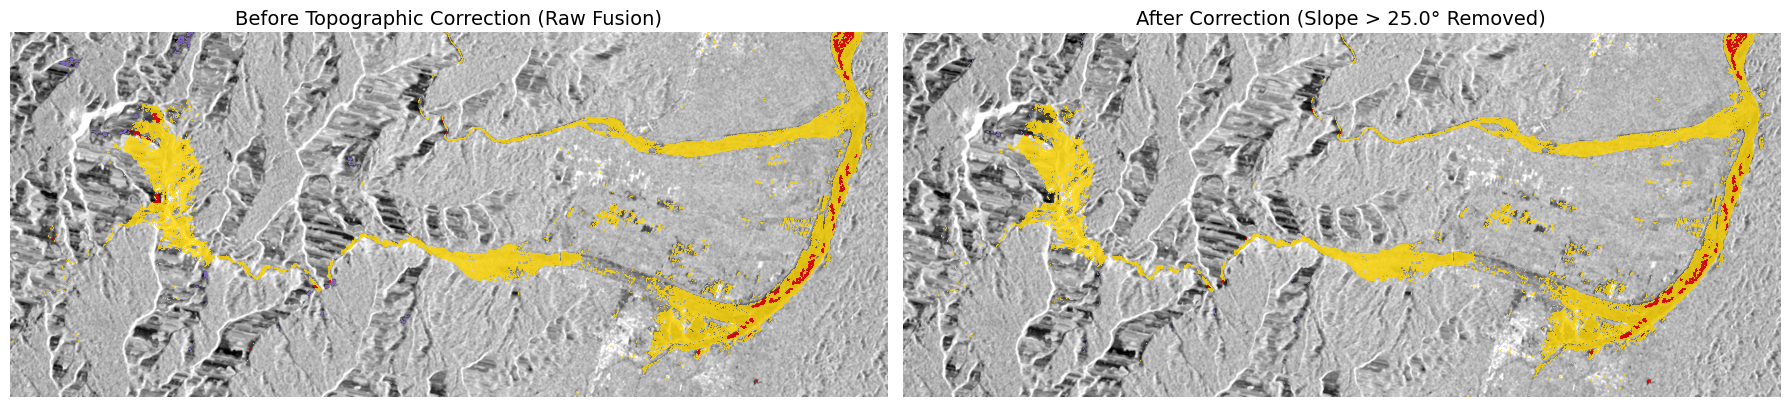

Task 3: 地形過濾誤報分析 (False Positives Removed)
--------------------------------------------------
25° - 35° 坡度區間移除了: 0.35 km²
35° - 45° 坡度區間移除了: 0.79 km²
> 45° 極陡坡區間移除了:   1.56 km²
--------------------------------------------------
總計移除地形誤報面積:      2.71 km²


In [14]:
# 1. 安全檢查：確保 DEM 與 SAR 遮罩大小完美對齊
if slope_deg.shape != cleaned_water_mask.shape:
    print("⚠️ 網格大小不一致，進行對齊...")
    from scipy.ndimage import zoom
    zoom_factors = (cleaned_water_mask.shape[0] / slope_deg.shape[0],
                    cleaned_water_mask.shape[1] / slope_deg.shape[1])
    # 坡度是連續數值，所以用 order=1 (Bilinear)
    slope_deg = zoom(slope_deg, zoom_factors, order=1) 

# 2. 找出位於陡坡上的「假水體」(False Positives)
# 條件：坡度大於閾值，且原本 SAR 說是水體的地方
false_positives_mask = (slope_deg > slope_threshold) & (cleaned_water_mask == True)

# 3. 計算各坡度區間被移除的誤報面積 (1 pixel = 0.0001 km²)
fp_25_35 = np.sum(false_positives_mask & (slope_deg >= 25) & (slope_deg < 35)) * 0.0001
fp_35_45 = np.sum(false_positives_mask & (slope_deg >= 35) & (slope_deg < 45)) * 0.0001
fp_45_plus = np.sum(false_positives_mask & (slope_deg >= 45)) * 0.0001
total_fp = fp_25_35 + fp_35_45 + fp_45_plus

# 4. 更新確信度地圖 (斬草除根！)
# 複製一份原本的確信度地圖
filtered_confidence_map = confidence_map.copy()
# 把判定為誤報的地方，強制歸零 (背景)
filtered_confidence_map[false_positives_mask] = 0

# 5. 繪製前後對比圖
fig, ax = plt.subplots(1, 2, figsize=(18, 7))
cmap_fusion = ListedColormap(['none', '#FFD700', '#9370DB', '#FF0000'])

# [左圖] 過濾前 (Before)
ax[0].imshow(vv_post_filtered, cmap='gray', vmin=-25, vmax=0)
ax[0].imshow(confidence_map, cmap=cmap_fusion, interpolation='none', alpha=0.8)
ax[0].set_title('Before Topographic Correction (Raw Fusion)', fontsize=14)
ax[0].axis('off')

# [右圖] 過濾後 (After)
ax[1].imshow(vv_post_filtered, cmap='gray', vmin=-25, vmax=0)
ax[1].imshow(filtered_confidence_map, cmap=cmap_fusion, interpolation='none', alpha=0.8)
ax[1].set_title(f'After Correction (Slope > {slope_threshold}° Removed)', fontsize=14)
ax[1].axis('off')

plt.tight_layout()
plt.show()

# 輸出作業要求的統計表
print("=" * 50)
print("Task 3: 地形過濾誤報分析 (False Positives Removed)")
print("-" * 50)
print(f"25° - 35° 坡度區間移除了: {fp_25_35:.2f} km²")
print(f"35° - 45° 坡度區間移除了: {fp_35_45:.2f} km²")
print(f"> 45° 極陡坡區間移除了:   {fp_45_plus:.2f} km²")
print("-" * 50)
print(f"總計移除地形誤報面積:      {total_fp:.2f} km²")
print("=" * 50)

在你的案例中，DEM 是否適合用於地形校正？為什麼？如果 DEM 不適用，你會用什麼替代方法清理假水體？

### Captain's Log 10: DEM 適用性討論 (Topographic Audit Reflection)

**在本次馬太鞍溪堰塞湖的案例中，DEM 是否適合用於地形校正？**
不完全適合。雖然使用 Copernicus DEM（多為 2011-2015 年觀測資料）成功過濾了高達 2.71 km² 的陡坡雷達誤報，但由於本次災害情境是「2025 年堰塞湖崩塌」，局部的真實地形（如崩塌區、新形成的大壩與積水區邊緣）已經發生劇烈改變。使用舊有的 DEM 坡度去過濾剛改變的地貌，可能會導致堰塞湖周圍真正積水但原本是陡坡的區域被誤刪（False Negatives）。

**替代/輔助方法：**
若 DEM 不適用於劇烈變動的災區，可以適用前者過濾的方法，利用水體通常呈現大面積連續分佈的物理特性，將孤立且破碎的地形雜訊剔除。

### Captain's Log 11: Task 4 戰略簡報自動生成 (via Groq API)

透過 Groq API (Llama 3 模型) 自動生成符合緊急應變顧問視角的戰略簡報，並直接在 Notebook 中以 Markdown 格式渲染顯示。最後進行兩週的比較。

In [18]:
import os
from dotenv import load_dotenv
from groq import Groq
from IPython.display import display, Markdown

# 1. Load keys and initialize Groq client
load_dotenv(override=True)
api_key = os.getenv("GROQ_API_KEY")

if not api_key:
    raise ValueError("Cannot find GROQ_API_KEY, please check your .env file!")

client = Groq(api_key=api_key)

# 2. Dynamically build our Prompt (injecting variables calculated earlier)
prompt_text = f"""
You are an emergency management advisor for Hualien County after Typhoon Fung-wong (November 2025). The Matai'an Creek barrier lake has overflowed, flooding Wanrong, Guangfu, and Fenglin townships.
Based on these ARIA v7.0 sensor fusion results, generate a strategic briefing that covers:
1. Which areas require immediate evacuation?
2. How should resources be allocated between high-confidence and SAR-only zones?
3. What are the limitations of the current assessment?
4. What additional data would improve confidence?

Key Metrics:
- High confidence flood area: {area_high_conf:.2f} km²
- SAR-only (cloudy) flood area: {area_sar_only:.2f} km²
- Optical-only (potential mud/shallow water): {area_optical_only:.2f} km²
- False positives removed by topographic filter: {total_fp:.2f} km²
- Cloud cover percentage: {best_s2_item.properties.get('eo:cloud_cover'):.2f}%
- SAR threshold: {sar_threshold} dB
- NDWI threshold: {ndwi_threshold}
"""

print("🚀 Calling Groq API to generate strategic briefing...\n")

# 3. Send request to the active Llama 3.1 70B model
chat_completion = client.chat.completions.create(
    messages=[
        {
            "role": "system",
            "content": "You are a professional emergency management advisor. Provide a structured, serious, and actionable strategic briefing."
        },
        {
            "role": "user",
            "content": prompt_text
        }
    ],
    # --- CHANGED MODEL NAME HERE ---
    model="llama-3.3-70b-versatile", 
    temperature=0.5, 
)

ai_response = chat_completion.choices[0].message.content

# 4. Render the Markdown result beautifully in Jupyter Notebook
display(Markdown("### 🤖 Strategic Briefing from Groq AI Advisor:"))
display(Markdown(ai_response))

🚀 Calling Groq API to generate strategic briefing...



### 🤖 Strategic Briefing from Groq AI Advisor:

**Strategic Briefing: Emergency Response to Flooding in Hualien County**

**Situation Overview:**
Typhoon Fung-wong has caused the Matai'an Creek barrier lake to overflow, resulting in significant flooding in Wanrong, Guangfu, and Fenglin townships. ARIA v7.0 sensor fusion results provide critical insights to inform emergency response efforts.

**I. Immediate Evacuation Areas:**
Based on the high-confidence flood area (0.86 km²), immediate evacuation is required for all residents and individuals in the following areas:

* Low-lying areas and floodplains along the Matai'an Creek
* Neighborhoods and communities with known flood vulnerabilities
* Areas with reported water levels exceeding 1 meter

Evacuation routes and shelters should be clearly designated, and emergency services should be deployed to assist in the evacuation process.

**II. Resource Allocation:**
Resources should be allocated as follows:

* High-confidence flood areas (0.86 km²): Prioritize deployment of emergency services, search and rescue (SAR) teams, and relief supplies to these areas.
* SAR-only (cloudy) flood areas (0.32 km²): Allocate secondary resources, including SAR teams and relief supplies, to these areas, taking into account the potential for hidden hazards and reduced visibility.
* Optical-only (potential mud/shallow water) areas (19.67 km²): Monitor these areas closely, and allocate resources as needed, focusing on potential mudslide or shallow water hazards.

**III. Limitations of Current Assessment:**
The current assessment has several limitations:

* Cloud cover percentage (44.91%) reduces the accuracy of optical satellite imagery, potentially leading to underestimation of flood extent.
* SAR-only areas may have hidden hazards, such as debris or swift water, which may not be fully captured by SAR imagery.
* The topographic filter removed 2.71 km² of false positives, but may have also removed some actual flood areas.

**IV. Additional Data to Improve Confidence:**
To improve confidence in the assessment, the following additional data would be beneficial:

* High-resolution optical satellite imagery (e.g., Planet Labs, WorldView) to supplement SAR data and reduce cloud cover limitations.
* Ground-based sensors and reports from emergency responders to validate flood extent and identify areas of high risk.
* LiDAR or other elevation data to improve topographic filtering and reduce false positives.
* Social media and crowd-sourced reports to gather information on affected areas and potential hazards.

**Recommendations:**

1. Continue to monitor the situation and update the assessment as new data becomes available.
2. Deploy emergency services and SAR teams to high-confidence flood areas and allocate secondary resources to SAR-only areas.
3. Establish a incident command system to coordinate response efforts and allocate resources effectively.
4. Consider deploying unmanned aerial vehicles (UAVs) or manned aircraft to gather additional imagery and data.

By following these recommendations and addressing the limitations of the current assessment, emergency responders can effectively allocate resources, prioritize evacuation efforts, and mitigate the impacts of the flooding in Hualien County.

reflection：
雖然LLM指出高信心度淹水區應列為最優先處理目標，因為這些區域同時具備 SAR（合成孔徑雷達）與光學影像的證實。但是若要作為實際的應變決策依據，仍需考量其他因素。因為透過衛星產製的淹水地圖仍具有不確定性，這些誤差可能來自於 SAR 的雜訊、地形失真，以及DEM本身的限制。在做出最終的緊急應變決策前，仍需綜合參考實地回報、無人機（UAV）影像，以及最新的水文資訊。

## ARIA v7.0 vs. v6.0 Comparison

Week 9 主要使用 Sentinel-2 光學影像與 ΔNDVI 進行災害變異偵測，因此結果反映的是較廣義的地表變化，例如植被破壞、崩塌、裸露地、陰影變化與潛在水體變化。而Week 10 加入 Sentinel-1 SAR 雷達資料，並與 Sentinel-2 NDWI、雲遮罩進行融合，因此更聚焦於淹水或水體相關偵測。

| 指標 | W9：Optical Only / ARIA v6.0 | W10：Fused / ARIA v7.0 | 說明 |
|---|---:|---:|---|
| 總偵測面積 | 114.48 km² | 20.85 km² | W9 偵測的是較廣義的光學變異區；W10 則將偵測結果細分為光學-only、SAR-only 與高確信度區，解釋上更保守 |
| 高確信度區域 | 73.36 km² | 0.86 km² | W10 的高確信度區必須同時受到 SAR 與光學 NDWI 支持，因此條件比 W9 更嚴格 |
| 低信心 / 光學-only 區域 | 41.12 km² | 19.67 km² | W10 將只有光學支持、但沒有 SAR 支持的區域標示為 Optical Only，代表需要人工檢查 |
| SAR 支持的淹水面積 | 無 | 1.18 km² | W10 新增 SAR 證據，其中包含 High Confidence 0.86 km² 與 SAR-only cloudy 0.32 km² |
| 雲遮蔽下仍可分析的淹水區 | 0 km² | 0.32 km² | W9 光學影像無法可靠觀測雲下地表；W10 可利用 SAR 穿透雲層進行偵測 |
| SAR 原始水體遮罩面積 | 無 | 4.33 km² | SAR 先偵測出低後向散射的水體候選區，再經融合與地形檢查進一步判讀 |
| 地形誤報移除 | 未套用 DEM 地形過濾 | 2.71 km² | W10 使用 slope > 25° 作為地形過濾條件，移除位於陡坡上的可能假水體 |
| 信心度分類 | 3 區：High / Low / No Detection | 4 類：No Detection / Optical Only / SAR Only / High Confidence | W10 的分類更細緻，能區分雙重證據、雷達-only、光學-only 與未偵測區 |
| 主要限制 | 容易受雲層、陰影、地形與光學變異混淆影響 | SAR 可能受斑點雜訊與陡坡地形失真影響 | W10 雖較穩健，但仍需要地面資料、UAV 或後續影像驗證 |

### Interpretation

兩週作業的偵測面積不同，無法直接從面積對比偵測結果，但仍可討論其結果。整體來看，W10 的偵測面積雖然小於 W9，我認為不代表 W10 的效果較差。而是 W10 的判讀流程更保守，也更能區分一般光學變異與有 SAR 支持的淹水證據。特別是在颱風後雲層遮蔽嚴重下，SAR-only cloudy 區域提供了 W9 光學方法無法取得的觀測能力。